# Feature engineering et préparation au Machine Learning

Ce notebook prépare les données pour les modèles de prédiction du risque.

Les objectifs sont :

- sélectionner les variables disponibles avant le sinistre ;
- exclure les identifiants et les sources de fuite ;
- effectuer un découpage temporel ;
- préparer séparément les variables numériques et binaires ;
- construire un pipeline de prétraitement reproductible.

In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

In [2]:
processed_data_path = Path(
    "../data/processed/cleaned_data.csv"
)

df = pd.read_csv(processed_data_path)

In [3]:
numerical_features = [
    "Age_client",
    "age_of_car_M",
    "Car_power_M",
    "Insuredcapital_content_re",
    "Insuredcapital_continent_re",
    "Client_Seniority"
]

In [4]:
binary_features = [
    "gender",
    "Car_2ndDriver_M",
    "num_policiesC",
    "metro_code",
    "Policy_PaymentMethodA",
    "Policy_PaymentMethodH",
    "appartment"
]

In [5]:
feature_columns = (
    numerical_features
    + binary_features
)

feature_columns

['Age_client',
 'age_of_car_M',
 'Car_power_M',
 'Insuredcapital_content_re',
 'Insuredcapital_continent_re',
 'Client_Seniority',
 'gender',
 'Car_2ndDriver_M',
 'num_policiesC',
 'metro_code',
 'Policy_PaymentMethodA',
 'Policy_PaymentMethodH',
 'appartment']

In [6]:
print(
    f"Nombre de variables explicatives : "
    f"{len(feature_columns)}"
)

Nombre de variables explicatives : 13


In [7]:
excluded_columns = [
    "PolID",
    "year",
    "Retention",
    "Types",
    "NClaims1",
    "NClaims2",
    "Claims1",
    "Claims2",
    "Total_NClaims",
    "Total_Claims",
    "Has_Claim",
    "Has_Paid_Claim",
    "Average_Claim_Severity"
]

## Sélection des variables

Les variables `PolID` et `year` ne sont pas utilisées directement comme prédicteurs. Elles servent respectivement au suivi des contrats et au découpage temporel.

Les variables de sinistres et les cibles dérivées sont exclues afin d’éviter les fuites de données.

La variable `Types` est exclue, car elle est directement liée à la nature des sinistres observés.

La variable `Retention` reste exclue tant que sa disponibilité avant le sinistre n’est pas confirmée.

In [8]:
missing_features = [
    column
    for column in feature_columns
    if column not in df.columns
]

missing_features

[]

In [9]:
assert len(missing_features) == 0, (
    f"Variables absentes : {missing_features}"
)

assert set(feature_columns).isdisjoint(
    excluded_columns
)

print("La sélection des variables est valide.")

La sélection des variables est valide.


In [10]:
classification_target = "Has_Claim"
frequency_target = "Total_NClaims"
cost_target = "Total_Claims"
severity_target = "Average_Claim_Severity"

In [11]:
train_mask = df["year"].isin([1, 2, 3])
validation_mask = df["year"] == 4
test_mask = df["year"] == 5

In [12]:
X_train = df.loc[
    train_mask,
    feature_columns
].copy()

y_train_classification = df.loc[
    train_mask,
    classification_target
].copy()

In [13]:
X_validation = df.loc[
    validation_mask,
    feature_columns
].copy()

y_validation_classification = df.loc[
    validation_mask,
    classification_target
].copy()

In [14]:
X_test = df.loc[
    test_mask,
    feature_columns
].copy()

y_test_classification = df.loc[
    test_mask,
    classification_target
].copy()

In [15]:
split_summary = pd.DataFrame({
    "Ensemble": [
        "Entraînement",
        "Validation",
        "Test"
    ],
    "Nombre_observations": [
        len(X_train),
        len(X_validation),
        len(X_test)
    ],
    "Taux_sinistre": [
        y_train_classification.mean() * 100,
        y_validation_classification.mean() * 100,
        y_test_classification.mean() * 100
    ]
})

split_summary.round(2)

,Ensemble,Nombre_observations,Taux_sinistre
0,Entraînement,92607,5.79
1,Validation,17044,5.07
2,Test,13284,4.67


In [16]:
assert (
    len(X_train)
    + len(X_validation)
    + len(X_test)
    == len(df)
)

print("Toutes les observations sont affectées à un ensemble.")

Toutes les observations sont affectées à un ensemble.


## 2. Pipeline de prétraitement

Les variables numériques sont standardisées, tandis que les variables binaires sont conservées sous leur forme 0/1.

Le préprocesseur est ajusté uniquement sur les années d’entraînement afin d’éviter toute fuite d’information depuis les années de validation et de test.

In [17]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "numerical",
            StandardScaler(),
            numerical_features
        ),
        (
            "binary",
            "passthrough",
            binary_features
        )
    ],
    remainder="drop",
    verbose_feature_names_out=False
)

In [18]:
(
    "numerical",
    StandardScaler(),
    numerical_features
)

('numerical',
 StandardScaler(),
 ['Age_client',
  'age_of_car_M',
  'Car_power_M',
  'Insuredcapital_content_re',
  'Insuredcapital_continent_re',
  'Client_Seniority'])

In [19]:
(
    "binary",
    "passthrough",
    binary_features
)

('binary',
 'passthrough',
 ['gender',
  'Car_2ndDriver_M',
  'num_policiesC',
  'metro_code',
  'Policy_PaymentMethodA',
  'Policy_PaymentMethodH',
  'appartment'])

In [20]:
preprocessor.set_output(
    transform="pandas"
)

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numerical', ...), ('binary', ...)]"
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``. e.g. ``""{feature_name}__{transformer_name}""``. See :meth:`str.format` method from the standard library for more info... versionadded:: 1.0.. versionchanged:: 1.6 `verbose_feature_names_out` can be a callable or a string to be formatted.",False
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transfo

In [21]:
X_train_prepared = preprocessor.fit_transform(
    X_train
)

In [22]:
X_validation_prepared = preprocessor.transform(
    X_validation
)

X_test_prepared = preprocessor.transform(
    X_test
)

In [23]:
X_train_prepared.head()

,Age_client,age_of_car_M,Car_power_M,Insuredcapital_content_re,Insuredcapital_continent_re,Client_Seniority,gender,Car_2ndDriver_M,num_policiesC,metro_code,Policy_PaymentMethodA,Policy_PaymentMethodH,appartment
0,1.920087,0.714191,-0.484622,-0.396016,0.079995,1.355464,1,0,1,0,0,1,0
1,1.843009,-1.400557,1.468650,-2.566209,0.033784,1.322043,1,0,1,0,1,1,0
2,1.997165,-1.400557,1.154330,0.065352,0.108359,1.683643,1,0,1,0,1,1,1
3,1.997165,-1.400557,-0.484622,2.591649,0.743001,2.060035,1,0,1,0,1,1,1
4,1.765932,1.852901,0.076663,0.099808,0.975327,-0.458011,1,0,1,0,1,1,1


In [24]:
print(
    "Dimensions avant prétraitement :",
    X_train.shape
)

print(
    "Dimensions après prétraitement :",
    X_train_prepared.shape
)

Dimensions avant prétraitement : (92607, 13)
Dimensions après prétraitement : (92607, 13)


In [25]:
assert X_train_prepared.shape[1] == len(
    feature_columns
)

print("Le nombre de variables est correct.")

Le nombre de variables est correct.


In [26]:
X_train_prepared.columns.tolist()

['Age_client',
 'age_of_car_M',
 'Car_power_M',
 'Insuredcapital_content_re',
 'Insuredcapital_continent_re',
 'Client_Seniority',
 'gender',
 'Car_2ndDriver_M',
 'num_policiesC',
 'metro_code',
 'Policy_PaymentMethodA',
 'Policy_PaymentMethodH',
 'appartment']

In [27]:
assert set(
    X_train_prepared.columns
) == set(feature_columns)

print("Toutes les variables attendues sont présentes.")

Toutes les variables attendues sont présentes.


In [28]:
standardization_check = pd.DataFrame({
    "Moyenne": X_train_prepared[
        numerical_features
    ].mean(),
    "Ecart_type": X_train_prepared[
        numerical_features
    ].std(ddof=0)
})

standardization_check.round(3)

,Moyenne,Ecart_type
Age_client,-0.0,1.0
age_of_car_M,-0.0,1.0
Car_power_M,-0.0,1.0
Insuredcapital_content_re,-0.0,1.0
Insuredcapital_continent_re,0.0,1.0
Client_Seniority,-0.0,1.0


In [29]:
for column in binary_features:
    print(
        column,
        sorted(
            X_train_prepared[column].unique()
        )
    )

gender [np.int64(0), np.int64(1)]
Car_2ndDriver_M [np.int64(0), np.int64(1)]
num_policiesC [np.int64(0), np.int64(1)]
metro_code [np.int64(0), np.int64(1)]
Policy_PaymentMethodA [np.int64(0), np.int64(1)]
Policy_PaymentMethodH [np.int64(0), np.int64(1)]
appartment [np.int64(0), np.int64(1)]


In [30]:
prepared_missing_values = pd.Series({
    "Entrainement": (
        X_train_prepared
        .isnull()
        .sum()
        .sum()
    ),
    "Validation": (
        X_validation_prepared
        .isnull()
        .sum()
        .sum()
    ),
    "Test": (
        X_test_prepared
        .isnull()
        .sum()
        .sum()
    )
})

prepared_missing_values

Entrainement    0
Validation      0
Test            0
dtype: int64

In [31]:
assert not X_train_prepared.isnull().any().any()
assert not X_validation_prepared.isnull().any().any()
assert not X_test_prepared.isnull().any().any()

print("Aucune valeur manquante après prétraitement.")

Aucune valeur manquante après prétraitement.


In [32]:
class_distribution = pd.DataFrame({
    "Effectif": (
        y_train_classification
        .value_counts()
        .sort_index()
    ),
    "Pourcentage": (
        y_train_classification
        .value_counts(normalize=True)
        .sort_index()
        .mul(100)
    )
})

class_distribution.round(2)

,Effectif,Pourcentage
Has_Claim,,
0,87241,94.21
1,5366,5.79


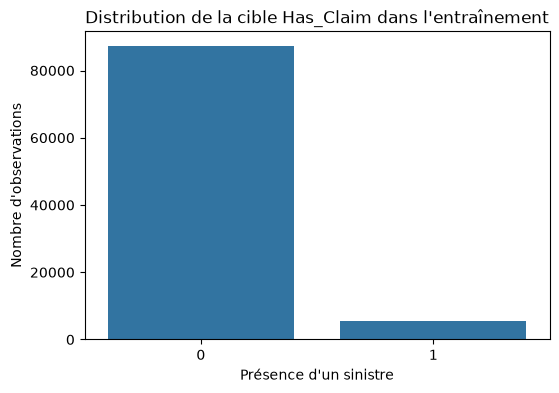

In [37]:
plt.figure(figsize=(6, 4))

sns.countplot(
    x=y_train_classification
)

plt.title(
    "Distribution de la cible Has_Claim "
    "dans l'entraînement"
)
plt.xlabel("Présence d'un sinistre")
plt.ylabel("Nombre d'observations")
plt.show()

In [38]:
negative_count = (
    y_train_classification == 0
).sum()

positive_count = (
    y_train_classification == 1
).sum()

class_weight_ratio = (
    negative_count / positive_count
)

print(
    "Ratio classe négative / classe positive : "
    f"{class_weight_ratio:.2f}"
)

Ratio classe négative / classe positive : 16.26


## Pipeline final

Dans le notebook de modélisation, le préprocesseur sera associé à un véritable modèle :

- régression logistique pour la baseline ;
- Random Forest ;
- Gradient Boosting.

Le pipeline garantira que le prétraitement et le modèle utilisent exactement les mêmes transformations pendant l’entraînement, la prédiction et le déploiement.